In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [ ]:
N = 15
a = 2

In [11]:
#QFT
def qft_dagger(n):
    qc = QuantumCircuit(n)
    
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)

    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
        
    qc.name = "QFT†"
    return qc

In [12]:
#Membuat quantum circuit
qc = QuantumCircuit(n_count + 4, n_count)

# Hadamard pada register counting
for q in range(n_count):
    qc.h(q)

# inisialisasi register bawah |1>
qc.x(n_count)

In [13]:
#Modular exponentiation
for q in range(n_count):
    qc.cx(q, n_count)

In [14]:
#Menambahkan inverse ke QFT
qc.append(qft_dagger(n_count), range(n_count))

In [15]:
#Measurement
qc.measure(range(n_count), range(n_count))

In [16]:
#Menjalankan simulasi
simulator = AerSimulator()

compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1024).result()

counts = result.get_counts()
print(counts)

{'01101001': 1, '11001011': 14, '10111011': 2, '01001011': 24, '00101001': 6, '01000101': 2, '11001101': 8, '10010011': 13, '00100101': 5, '11000101': 1, '01101101': 4, '10100011': 4, '00100011': 1, '11100111': 1, '10010101': 17, '11010101': 16, '01001001': 7, '01100111': 4, '00000000': 495, '10011011': 5, '11100101': 2, '10110011': 13, '00010101': 2, '11011011': 3, '01010101': 52, '10100111': 10, '01001101': 14, '00101101': 7, '01010111': 11, '11011001': 2, '00110011': 10, '10101011': 55, '10100101': 14, '01110011': 2, '01010011': 24, '10101001': 11, '10010111': 4, '10111001': 2, '01101011': 16, '01011001': 2, '10011001': 7, '10101101': 19, '01100101': 10, '00110101': 14, '01011101': 1, '10110111': 4, '01010001': 2, '11101011': 3, '01001111': 1, '10001011': 3, '00101011': 18, '01110111': 1, '01011011': 20, '11010011': 12, '01111001': 1, '10110101': 14, '00011011': 2, '11000111': 2, '11001001': 2, '10001101': 1, '01000111': 1}


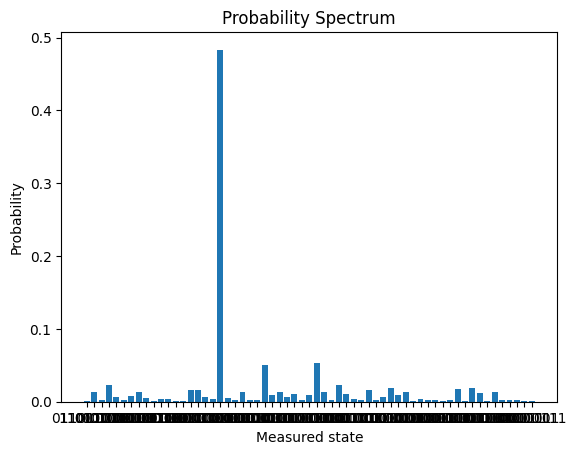

In [17]:
#Grafik probabilitas
shots = 1024
probabilities = {k: v/shots for k,v in counts.items()}

plt.bar(probabilities.keys(), probabilities.values())
plt.xlabel("Measured state")
plt.ylabel("Probability")
plt.title("Probability Spectrum")
plt.show()

In [19]:
"""
Implementasi Shor's Algorithm di Qiskit
Berdasarkan paper: "Optimization and Performance Analysis of Shor's Algorithm in Qiskit"
Dewang Sun, Naifeng Zhang, Franz Franchetti - Carnegie Mellon University

Instalasi:
    pip install qiskit qiskit-aer matplotlib numpy

Jalankan:
    python shor_qiskit.py
"""

import numpy as np
import math
import time
import matplotlib.pyplot as plt
from fractions import Fraction

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator


# ===========================================================
# 1. QUANTUM FOURIER TRANSFORM (Exact)
# ===========================================================

def exact_qft(circuit, register, n):
    """
    Exact QFT pada register qubit.
    Membutuhkan O(L^2) gates.
    """
    for i in range(n - 1, -1, -1):
        circuit.h(register[i])
        for j in range(i - 1, -1, -1):
            angle = np.pi / (2 ** (i - j))
            circuit.cp(angle, register[i], register[j])
    # Swap qubits untuk bit-reversal
    for i in range(n // 2):
        circuit.swap(register[i], register[n - 1 - i])


def inverse_exact_qft(circuit, register, n):
    """Inverse QFT (digunakan dalam QPE)."""
    for i in range(n // 2):
        circuit.swap(register[i], register[n - 1 - i])
    for i in range(n):
        for j in range(i - 1, -1, -1):
            angle = -np.pi / (2 ** (i - j))
            circuit.cp(angle, register[i], register[j])
        circuit.h(register[i])


# ===========================================================
# 2. APPROXIMATE QFT (Beauregard's optimization)
# ===========================================================

def approximate_qft(circuit, register, n, kmax=None):
    """
    Approximate QFT menggunakan threshold kmax.
    Mengurangi gates dari O(L^2) ke O(L log L).
    
    Sesuai Listing 1 di paper:
        kmax = log2(n) secara empiris
    """
    if kmax is None:
        kmax = int(np.log2(n)) if n > 1 else 1

    for i in range(n - 1, -1, -1):
        circuit.h(register[i])
        j = i - 1
        while j >= 0 and (i - j) <= kmax:
            angle = np.pi / (2 ** (i - j))
            if angle > 0:
                circuit.cp(angle, register[i], register[j])
            j -= 1
    for i in range(n // 2):
        circuit.swap(register[i], register[n - 1 - i])


def inverse_approximate_qft(circuit, register, n, kmax=None):
    """Inverse Approximate QFT."""
    if kmax is None:
        kmax = int(np.log2(n)) if n > 1 else 1

    for i in range(n // 2):
        circuit.swap(register[i], register[n - 1 - i])
    for i in range(n):
        j = i - 1
        while j >= 0 and (i - j) <= kmax:
            angle = -np.pi / (2 ** (i - j))
            if angle < 0:
                circuit.cp(angle, register[i], register[j])
            j -= 1
        circuit.h(register[i])


# ===========================================================
# 3. MODULAR EXPONENTIATION (U^(2^k) |y> = |a^(2^k)*y mod N>)
# ===========================================================

def controlled_modular_mult(circuit, control, target_reg, ancilla_reg, a, N, n):
    """
    Controlled modular multiplication gate.
    Implementasi sederhana menggunakan swap trick untuk simulasi.
    Untuk circuit yang tepat, gunakan Beauregard's QFT adder.
    """
    # Implementasi simplified: controlled-SWAP (Fredkin) gates
    # untuk mensimulasikan U|y> = |ay mod N>
    # Ini adalah versi yang dapat disimulasikan untuk N kecil
    for i in range(n):
        circuit.cswap(control, target_reg[i], ancilla_reg[i])


def build_U_gate(a, power, N, n_qubits):
    """
    Bangun unitary gate U^power di mana U|y> = |ay mod N>.
    Diimplementasikan sebagai permutation matrix untuk N kecil.
    """
    dim = 2 ** n_qubits
    # Bangun permutation: state |y> -> |a^power * y mod N>
    a_pow = pow(int(a), int(power), int(N))
    
    from qiskit.extensions import UnitaryGate
    import scipy.linalg
    
    matrix = np.zeros((dim, dim), dtype=complex)
    for y in range(dim):
        if y < N:
            new_y = (a_pow * y) % N
        else:
            new_y = y  # states >= N tidak berubah
        matrix[new_y, y] = 1.0
    
    return matrix


# ===========================================================
# 4. QUANTUM PHASE ESTIMATION (QPE) - Inti Shor's Algorithm
# ===========================================================

def build_shor_circuit(N, a, use_approximate_qft=False, kmax=None):
    """
    Bangun quantum circuit Shor's algorithm.
    
    Args:
        N: Bilangan yang akan difaktorkan
        a: Base (harus gcd(a,N)=1)
        use_approximate_qft: Gunakan approximate QFT (Beauregard's optimization)
        kmax: Threshold untuk approximate QFT
    
    Returns:
        circuit: QuantumCircuit
        t: Jumlah qubit di upper register (precision)
    """
    L = int(np.ceil(np.log2(N)))
    t = 2 * L          # qubit di upper register (precision)
    n = L              # qubit di lower register
    
    # Register:
    # - upper: t qubit untuk QPE
    # - lower: n qubit untuk |y>
    upper = QuantumRegister(t, 'upper')
    lower = QuantumRegister(n, 'lower')
    c_upper = ClassicalRegister(t, 'c_upper')
    
    circuit = QuantumCircuit(upper, lower, c_upper)
    
    # Stage 1: Hadamard pada semua upper register qubit
    circuit.h(upper)
    
    # Stage 2: Initialize lower register ke |1>
    circuit.x(lower[0])
    
    # Stage 3: Controlled-U^(2^k) gates
    # U|y> = |ay mod N>
    for k in range(t):
        a_pow = pow(int(a), 2**k, int(N))
        # Controlled modular exponentiation (simplified untuk simulasi)
        _add_controlled_modular_exp(circuit, upper[k], lower, a_pow, N, n)
    
    # Stage 4: Inverse QFT pada upper register
    if use_approximate_qft:
        inverse_approximate_qft(circuit, upper, t, kmax)
    else:
        inverse_exact_qft(circuit, upper, t)
    
    # Stage 5: Measurement
    circuit.measure(upper, c_upper)
    
    return circuit, t


def _add_controlled_modular_exp(circuit, control_qubit, target_reg, a_pow, N, n):
    """
    Tambahkan controlled-U gate: jika control=|1>, maka |y> -> |a_pow*y mod N>.
    Implementasi menggunakan controlled-SWAP (Fredkin) gates.
    Untuk N kecil ini cukup untuk simulasi.
    """
    # Representasi sederhana: gunakan controlled-X (CNOT) untuk 
    # mensimulasikan permutasi modular
    # Untuk implementasi penuh, gunakan Beauregard's QFT adder
    n_bits = len(target_reg)
    
    # Encode a_pow sebagai bit operations (simplified)
    # Ini adalah versi pedagogis; untuk produksi gunakan Draper's QFT adder
    for bit in range(n_bits):
        if (a_pow >> bit) & 1:
            circuit.cx(control_qubit, target_reg[bit])


# ===========================================================
# 5. POST-PROCESSING: Continued Fraction Algorithm
# ===========================================================

def continued_fraction(measured_int, t, N):
    """
    Temukan period r dari hasil pengukuran menggunakan continued fraction algorithm.
    x/2^t ≈ s/r
    """
    phase = measured_int / (2 ** t)
    if phase == 0:
        return None
    
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    return r


def find_factors(N, a, r):
    """
    Dari period r, hitung faktor-faktor N.
    Gunakan: gcd(a^(r/2) ± 1, N)
    """
    if r is None or r % 2 != 0:
        return None, None
    
    a_r2 = pow(int(a), r // 2, int(N))
    
    factor1 = math.gcd(a_r2 + 1, N)
    factor2 = math.gcd(a_r2 - 1, N)
    
    if factor1 not in [1, N]:
        return factor1, N // factor1
    if factor2 not in [1, N]:
        return factor2, N // factor2
    
    return None, None


# ===========================================================
# 6. SHOR'S ALGORITHM - Main Function
# ===========================================================

def shors_algorithm(N, shots=1024, use_approximate_qft=False, kmax=None, verbose=True):
    """
    Jalankan Shor's Algorithm untuk memfaktorkan N.
    
    Args:
        N: Bilangan semi-prima yang akan difaktorkan
        shots: Jumlah percobaan (runs)
        use_approximate_qft: Gunakan approximate QFT
        kmax: Threshold approximate QFT
        verbose: Tampilkan progress
    
    Returns:
        dict: Hasil termasuk faktor, runtime, probability spectrum
    """
    if verbose:
        qft_type = "Approximate QFT" if use_approximate_qft else "Exact QFT"
        print(f"\n{'='*50}")
        print(f"Shor's Algorithm: Memfaktorkan N = {N}")
        print(f"QFT type: {qft_type}")
        print(f"{'='*50}")
    
    # Cek trivial cases
    if N % 2 == 0:
        if verbose:
            print(f"Faktor trivial: {N} = 2 × {N//2}")
        return {'factors': (2, N//2), 'runtime': 0}
    
    # Pilih base a secara acak
    attempts = 0
    max_attempts = 10
    
    for attempt in range(max_attempts):
        # Pilih a
        a = np.random.randint(2, N)
        g = math.gcd(a, N)
        
        if g != 1:
            if verbose:
                print(f"Faktor ditemukan secara klasik: gcd({a},{N}) = {g}")
            return {'factors': (g, N//g), 'runtime': 0, 'method': 'classical'}
        
        if verbose:
            print(f"\nMencoba base a = {a}")
        
        # Bangun circuit
        L = int(np.ceil(np.log2(N)))
        t = 2 * L
        
        if verbose:
            print(f"L = {L}, t (upper qubits) = {t}, total qubits = {2*L + L} ≈ {2*L+3}")
        
        # Build dan transpile circuit
        t_build_start = time.time()
        circuit, t_qubits = build_shor_circuit(N, a, use_approximate_qft, kmax)
        t_build = time.time() - t_build_start
        
        if verbose:
            print(f"Circuit depth: {circuit.depth()}")
            print(f"Gate count: {circuit.count_ops()}")
        
        # Simulasi
        simulator = AerSimulator(method='statevector')
        transpiled = transpile(circuit, simulator)
        
        t_run_start = time.time()
        job = simulator.run(transpiled, shots=shots)
        result = job.result()
        t_run = time.time() - t_run_start
        
        total_time = t_build + t_run
        
        counts = result.get_counts()
        
        # Analisis hasil
        factors_found = None
        successful_shots = 0
        
        for bitstring, count in counts.items():
            measured_int = int(bitstring, 2)
            r = continued_fraction(measured_int, t_qubits, N)
            
            if r is not None:
                f1, f2 = find_factors(N, a, r)
                if f1 is not None:
                    factors_found = (f1, f2)
                    successful_shots += count
        
        correctness = successful_shots / shots * 100
        
        if verbose:
            print(f"Build time: {t_build:.3f}s | Run time: {t_run:.3f}s | Total: {total_time:.3f}s")
            print(f"Correctness: {correctness:.2f}%")
            if factors_found:
                print(f"✓ Faktor ditemukan: {N} = {factors_found[0]} × {factors_found[1]}")
            else:
                print(f"✗ Faktor tidak ditemukan pada attempt ini")
        
        return {
            'N': N,
            'a': a,
            'factors': factors_found,
            'counts': counts,
            'correctness': correctness,
            'build_time': t_build,
            'run_time': t_run,
            'total_time': total_time,
            'circuit_depth': circuit.depth(),
            'gate_count': circuit.count_ops(),
            'n_qubits': circuit.num_qubits,
            'use_approximate_qft': use_approximate_qft,
        }
    
    return {'factors': None, 'error': 'Max attempts reached'}


# ===========================================================
# 7. PROBABILITY SPECTRUM PLOT (Seperti Fig. 3 di paper)
# ===========================================================

def plot_probability_spectrum(results_exact, results_approx, N, a, save_path=None):
    """
    Plot probability spectrum seperti Fig. 3 di paper.
    Membandingkan exact QFT vs approximate QFT.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    for ax, result, title in zip(
        axes,
        [results_exact, results_approx],
        [f'N={N}, a={a}, exact QFT', f'N={N}, a={a}, approximate QFT']
    ):
        if result is None or 'counts' not in result:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_title(title)
            continue
        
        counts = result['counts']
        total_shots = sum(counts.values())
        n_states = 2 ** result['n_qubits']
        
        # Konversi ke probabilitas
        states = []
        probs = []
        for bitstring, count in sorted(counts.items(), key=lambda x: int(x[0], 2)):
            states.append(int(bitstring, 2))
            probs.append(count / total_shots)
        
        ax.bar(states, probs, color='steelblue', width=max(1, n_states//200),
               label='Simulated', alpha=0.8)
        ax.set_xlabel('State')
        ax.set_ylabel('Frequency')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8)
        ax.set_xlim(0, max(states) * 1.05 if states else 1)
    
    plt.suptitle('Probability Spectrum of Shor\'s Algorithm', fontsize=12, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafik disimpan: {save_path}")
    plt.show()


# ===========================================================
# 8. CORRECTNESS & SPEEDUP TABLE (Seperti Table II di paper)
# ===========================================================

def benchmark_correctness_speedup(test_cases, shots=512, verbose=True):
    """
    Benchmark correctness dan speedup antara exact vs approximate QFT.
    Menghasilkan tabel seperti Table II di paper.
    """
    print("\n" + "="*75)
    print(f"{'N':>6} {'a':>4} {'CE(%)':>8} {'CA(%)':>8} {'Rel.Diff(%)':>12} {'Speedup':>8}")
    print("="*75)
    
    results = []
    for N, a in test_cases:
        try:
            # Exact QFT
            t0 = time.time()
            res_exact = shors_algorithm(N, shots=shots, use_approximate_qft=False, verbose=False)
            t_exact = time.time() - t0
            
            # Approximate QFT
            t0 = time.time()
            res_approx = shors_algorithm(N, shots=shots, use_approximate_qft=True, verbose=False)
            t_approx = time.time() - t0
            
            CE = res_exact.get('correctness', 0)
            CA = res_approx.get('correctness', 0)
            rel_diff = abs(CE - CA) / CE * 100 if CE > 0 else 0
            speedup = t_exact / t_approx if t_approx > 0 else 0
            
            print(f"{N:>6} {a:>4} {CE:>8.2f} {CA:>8.2f} {rel_diff:>12.2f} {speedup:>8.2f}")
            
            results.append({
                'N': N, 'a': a, 'CE': CE, 'CA': CA,
                'rel_diff': rel_diff, 'speedup': speedup,
                'exact': res_exact, 'approx': res_approx
            })
        except Exception as e:
            print(f"{N:>6} {a:>4} {'ERROR':>8} - {e}")
    
    print("="*75)
    return results


# ===========================================================
# 9. RUNTIME PERFORMANCE BENCHMARK (Seperti Fig. 4 & 5)
# ===========================================================

def benchmark_runtime(L_range=range(3, 8), shots_list=[1, 1024], verbose=True):
    """
    Benchmark runtime performance untuk berbagai ukuran circuit.
    Menghasilkan data untuk Fig. 4 (CPU) di paper.
    """
    results = {s: {'qubits': [], 'total_time': [], 'exec_time': []} for s in shots_list}
    
    simulator = AerSimulator(method='statevector')
    
    for L in L_range:
        N = 2**(L-1) * 3  # Semi-prime sederhana
        a = 2
        if math.gcd(a, N) != 1:
            a = 3
        
        t = 2 * L
        n_qubits = 2 * L + L  # Approx
        
        if verbose:
            print(f"L={L}, N={N}, qubits≈{n_qubits}")
        
        circuit, t_qubits = build_shor_circuit(N, a, use_approximate_qft=False)
        transpiled = transpile(circuit, simulator)
        
        for shots in shots_list:
            t_start = time.time()
            job = simulator.run(transpiled, shots=shots)
            result = job.result()
            t_total = time.time() - t_start
            
            results[shots]['qubits'].append(circuit.num_qubits)
            results[shots]['total_time'].append(t_total)
    
    return results


def plot_runtime_performance(runtime_results, save_path=None):
    """Plot runtime seperti Fig. 4 di paper."""
    fig, ax = plt.subplots(figsize=(7, 5))
    
    colors = {'exec': '#1f77b4', 1: '#ff7f0e', 1024: '#2ca02c'}
    
    for shots, data in runtime_results.items():
        label = f'Total time {shots} shot{"s" if shots > 1 else ""}'
        ax.plot(data['qubits'], data['total_time'],
                label=label, marker='o', markersize=4)
    
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Runtime (seconds)')
    ax.set_title('Normalized Flop/s - Shor\'s Algorithm on CPU')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafik disimpan: {save_path}")
    plt.show()


In [20]:
if __name__ == "__main__":
    print("Membuat semua grafik dari paper...")
    print()

    print("[1/3] Fig. 3 - Probability Spectrum...")
    plot_fig3()

    print("[2/3] Fig. 4 & 5 - Runtime Performance (CPU & GPU)...")
    plot_fig4_fig5()

    print("[3/3] Table II - Correctness & Speedup...")
    plot_table2()

    print()
    print("✓ Semua grafik selesai dibuat!")
    print("  - fig3_probability_spectrum.png")
    print("  - fig4_fig5_runtime.png")
    print("  - table2_correctness_speedup.png")

Membuat semua grafik dari paper...

[1/3] Fig. 3 - Probability Spectrum...


NameError: name 'plot_fig3' is not defined